# Clase 7 Análisis de Datos

## 20260509

Librerías

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import re
import seaborn as sns
from datetime import date
from scipy.stats import probplot
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders.binary import BinaryEncoder
import math
from sklearn.mixture import GaussianMixture

Descripción de variables, paso 1 definición de variable objetivo

* `device_type`: Tipo de dispositivo (ej. laptop, desktop)
* `brand`: Marca del dispositivo
* `model`: Modelo del dispositivo
* `release_year`: Año de lanzamiento del dispositivo
* `os`: Sistema operativo instalado
* `form_factor`: Factor de forma o diseño del dispositivo (ej. laptop, ultrabook, desktop tower)
* `cpu_brand`: Marca del procesador
* `cpu_tier`: Nivel o gama del procesador, ordinal del 1 al 6 según desempeño
* `cpu_cores`: Número de núcleos del procesador
* `cpu_threads`: Número de hilos de ejecución del procesador
* `gpu_brand`: Marca de la tarjeta gráfica
* `gpu_model`: Modelo específico de la tarjeta gráfica
* `gpu_tier`: Nivel o gama de la GPU, ordinal del 1 al 6 según desempeño
* `vram_gb`: Memoria de video de la GPU en gigabytes
* `ram_gb`: Memoria RAM del dispositivo en gigabytes
* `storage_type`: Tipo de almacenamiento (ej. HDD, SSD)
* `storage_gb`: Capacidad de almacenamiento en gigabytes
* `storage_drive_count`: Número de unidades de almacenamiento instaladas
* `display_type`: Tipo de pantalla (ej. IPS, TN, OLED)
* `charger_watts`: Potencia del cargador (en watts) para laptops
* `psu_watts`: Potencia de la fuente de poder (en watts) para desktops
* `wifi`: Estándar de conectividad Wi-Fi (ej. Wi-Fi 5, 6, 6E, 7)
* `bluetooth`: Versión de Bluetooth
* `weight_kg`: Peso del dispositivo en kilogramos
* `warranty_months`: Meses de garantía del dispositivo
* `price`: Precio del dispositivo. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

Paso 2 importar datos

In [3]:
compu_df = pd.read_csv("../INPUT/computer_prices.csv")

# https://www.kaggle.com/datasets/paperxd/all-computer-prices

Paso 3 Analisis exploratorio

In [4]:
compu_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  str    
 1   brand                100000 non-null  str    
 2   model                100000 non-null  str    
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  str    
 5   form_factor          100000 non-null  str    
 6   cpu_brand            100000 non-null  str    
 7   cpu_model            100000 non-null  str    
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  gpu_brand            100000 non-null  str    
 12  gpu_model            100000 non-null  str    
 13  gpu_tier             100000 non-null  int64  
 14  vram_gb              100000 non-null  int64  
 15  ram_gb               100000 n

In [5]:
# conteo de variables por tipo de dato
compu_df.dtypes.value_counts()

str        12
int64      12
float64     3
Name: count, dtype: int64

In [6]:
# valores unicos por columna
compu_df.nunique().sort_values(ascending=False).to_frame(name="nunique")

,nunique
model,99036
cpu_model,26971
price,3366
gpu_model,49
weight_kg,47
cpu_threads,25
ram_gb,15
cpu_cores,12
brand,10
form_factor,10


In [7]:
# duplicados
n_dup = compu_df.duplicated().sum()
pct_dup = (n_dup / len(compu_df) * 100) if len(compu_df) > 0 else 0
print(f"Número de filas duplicadas: {n_dup} ({pct_dup:.2f}%)")

Número de filas duplicadas: 0 (0.00%)


In [8]:
# missings por columna
missing_counts = compu_df.isnull().sum()
missing_percentages = ((missing_counts / len(compu_df) * 100).round(2)) if len(compu_df) > 0 else 0
missing_df = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_percentage': missing_percentages
}).sort_values(by='missing_percentage', ascending=False)

display(missing_df)

,missing_count,missing_percentage
device_type,0,0.0
brand,0,0.0
model,0,0.0
release_year,0,0.0
os,0,0.0
form_factor,0,0.0
cpu_brand,0,0.0
cpu_model,0,0.0
cpu_tier,0,0.0
cpu_cores,0,0.0


In [9]:
# estadisticas descriptivas de variables numericas
numeric_cols = compu_df.select_dtypes(include=[np.number]).columns.tolist()
base_num = compu_df[numeric_cols]
n_rows = base_num.shape[0]
desc = base_num.describe(percentiles=[0.01,0.05,0.25, 0.5, 0.75, 0.95, 0.99]).T

desc["n_unicos"] = base_num.nunique()
desc["n_missings"] = base_num.isnull().sum()
desc["pct_missings"] = (desc["n_missings"] / n_rows * 100) if n_rows > 0 else 0
desc["skew"] = base_num.skew()
desc["kurt"] = base_num.kurtosis()

cols_orden = ["count","mean", "std", "min", "1%", "5%", "25%", "50%", "75%", "95%", "99%", "max","n_missings","pct_missings" ,"skew", "kurt"]

desc = desc[cols_orden]

display(desc)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,n_missings,pct_missings,skew,kurt
release_year,100000.0,2022.320850,2.025761,2018.00,2018.00,2018.00,2021.00,2023.00,2024.00,2025.00,2025.00,2025.00,0,0.0,-0.479062,-0.715846
cpu_tier,100000.0,3.153490,1.373175,1.00,1.00,1.00,2.00,3.00,4.00,5.00,6.00,6.00,0,0.0,0.174307,-0.751699
cpu_cores,100000.0,10.515740,5.044092,4.00,4.00,4.00,6.00,8.00,14.00,20.00,26.00,28.00,0,0.0,1.087762,1.007646
cpu_threads,100000.0,19.372700,9.718426,4.00,6.00,8.00,12.00,16.00,24.00,36.00,52.00,56.00,0,0.0,1.125744,1.300012
gpu_tier,100000.0,2.991350,1.459643,1.00,1.00,1.00,2.00,3.00,4.00,6.00,6.00,6.00,0,0.0,0.285752,-0.851269
vram_gb,100000.0,6.152180,3.964926,0.00,0.00,0.00,4.00,6.00,8.00,12.00,16.00,16.00,0,0.0,0.281362,-0.354864
ram_gb,100000.0,39.706400,31.902684,8.00,8.00,8.00,16.00,32.00,64.00,96.00,128.00,144.00,0,0.0,1.049278,0.195870
storage_gb,100000.0,903.936000,774.243654,256.00,256.00,256.00,512.00,512.00,1024.00,2048.00,4096.00,4096.00,0,0.0,2.304037,6.272154
storage_drive_count,100000.0,1.524980,0.797284,1.00,1.00,1.00,1.00,1.00,2.00,3.00,4.00,4.00,0,0.0,1.540038,1.746179
charger_watts,100000.0,61.383450,62.795034,0.00,0.00,0.00,0.00,65.00,90.00,180.00,240.00,240.00,0,0.0,0.855735,0.238015


Text(0.5, 1.0, 'Distribución de cpu_tier')

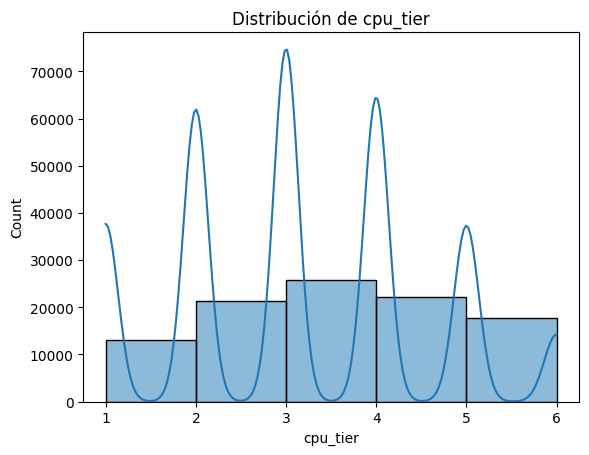

In [10]:
# histograma de cpu_tier
sns.histplot(data=compu_df, x="cpu_tier", bins=5, kde=True)
plt.title("Distribución de cpu_tier")

In [11]:
# estadisticas descriptivas de variables categoricas (tabla de frecuencias)

cat_types = ["object", "category", "bool", "string"]
columnas_cat = compu_df.select_dtypes(include=cat_types).columns.tolist()
n_total = len(compu_df)
resumen_rows = []

for col in columnas_cat:
    s = compu_df[col]
    vc = s.value_counts(dropna=False)
    niveles_totales = int(len(vc))
    unicos_no_na = int(s.nunique(dropna=True))
    na_count = int(s.isna().sum())
    na_pct = (na_count / n_total * 100.0) if n_total > 0 else 0.0
    top = vc
    freq_df = top.reset_index()
    freq_df.columns = [col, 'frecuencia']

    freq_df['valor'] = freq_df[col].apply(lambda x: 'NaN' if pd.isna(x) else str(x))
    freq_df = freq_df.drop(columns=[col])

    if n_total > 0:
        freq_df['%'] = (freq_df['frecuencia'] / n_total * 100.0).round(2)
    else:
        freq_df['%'] = 0.0

    if niveles_totales > len(top):
        otros_cnt = int(vc.iloc[len(top):].sum())
        otros_pct = (otros_cnt / n_total * 100.0) if n_total > 0 else 0.0
        freq_df = pd.concat([freq_df,pd.DataFrame({'valor': ['Otros'], 'frecuencia': [otros_cnt], '%': [round(otros_pct, 2)]})],ignore_index=True)

    freq_df['%_acum'] = freq_df['%'].cumsum().round(2)
    freq_df.insert(0, 'rank', np.arange(1, len(freq_df) + 1))
    resumen_rows.append({'columna': col,'unicos': niveles_totales,'unicos_no_na': unicos_no_na,
                         'NA': na_count,'%_NA': round(na_pct, 2),'frecuencia': n_total})

resumen = pd.DataFrame(resumen_rows)
resumen = resumen.sort_values(['frecuencia', 'unicos_no_na'], ascending=False)

display(resumen)

,columna,unicos,unicos_no_na,NA,%_NA,frecuencia
2,model,99036,99036,0,0.0,100000
6,cpu_model,26971,26971,0,0.0,100000
8,gpu_model,49,49,0,0.0,100000
1,brand,10,10,0,0.0,100000
4,form_factor,10,10,0,0.0,100000
10,display_type,6,6,0,0.0,100000
3,os,4,4,0,0.0,100000
7,gpu_brand,4,4,0,0.0,100000
9,storage_type,4,4,0,0.0,100000
11,wifi,4,4,0,0.0,100000


In [12]:
# frecuencia por variable para categóricas

for col in columnas_cat:
    s = compu_df[col]
    vc = s.value_counts(dropna=False)

    freq_df = (vc.rename('frecuencia').reset_index().rename(columns={'index': col}))
    freq_df[col] = freq_df[col].astype(object).where(~freq_df[col].isna(), 'NaN').astype(str)
    freq_df['%'] = (freq_df['frecuencia'] / n_total * 100.0).round(2)
    freq_df['%_acum'] = freq_df['%'].cumsum().round(2)
    freq_df.insert(0, 'rank', np.arange(1, len(freq_df) + 1))

    display(freq_df)

,rank,device_type,frecuencia,%,%_acum
0,1,Laptop,59844,59.84,59.84
1,2,Desktop,40156,40.16,100.00


,rank,brand,frecuencia,%,%_acum
0,1,Lenovo,15992,15.99,15.99
1,2,HP,14114,14.11,30.10
2,3,Dell,14005,14.00,44.10
3,4,Apple,11915,11.92,56.02
4,5,ASUS,10159,10.16,66.18
5,6,Acer,9925,9.93,76.11
6,7,Samsung,8066,8.07,84.18
7,8,MSI,7891,7.89,92.07
8,9,Gigabyte,4900,4.90,96.97
9,10,Razer,3033,3.03,100.00


,rank,model,frecuencia,%,%_acum
0,1,ASUS Slim R6S,3,0.0,0.0
1,2,Acer Creator 3U0,3,0.0,0.0
2,3,HP Creator R41,3,0.0,0.0
3,4,Samsung Pro HRZ,3,0.0,0.0
4,5,Lenovo Think 0V5,3,0.0,0.0
...,...,...,...,...,...
99031,99032,ASUS Pro ZWL,1,0.0,0.0
99032,99033,Lenovo Stealth 014,1,0.0,0.0
99033,99034,ASUS Zen LKD,1,0.0,0.0
99034,99035,ASUS Blade DH6,1,0.0,0.0


,rank,os,frecuencia,%,%_acum
0,1,Windows,71817,71.82,71.82
1,2,macOS,18207,18.21,90.03
2,3,Linux,6109,6.11,96.14
3,4,ChromeOS,3867,3.87,100.01


,rank,form_factor,frecuencia,%,%_acum
0,1,Mainstream,17819,17.82,17.82
1,2,Gaming,16876,16.88,34.70
2,3,ATX,15597,15.60,50.30
3,4,Ultrabook,13236,13.24,63.54
4,5,Micro-ATX,8672,8.67,72.21
5,6,Full-Tower,7110,7.11,79.32
6,7,2-in-1,7049,7.05,86.37
7,8,SFF,5585,5.58,91.95
8,9,Workstation,4864,4.86,96.81
9,10,Mini-ITX,3192,3.19,100.00


...

,rank,gpu_brand,frecuencia,%,%_acum
0,1,NVIDIA,54712,54.71,54.71
1,2,Apple,18922,18.92,73.63
2,3,AMD,15767,15.77,89.40
3,4,Intel,10599,10.60,100.00


,rank,gpu_model,frecuencia,%,%_acum
0,1,Apple Integrated,18922,18.92,18.92
1,2,RTX 40 70,5743,5.74,24.66
2,3,RTX 30 70,5692,5.69,30.35
3,4,RTX 40 60,5437,5.44,35.79
4,5,RTX 30 60,5314,5.31,41.10
5,6,RTX 30 50,5046,5.05,46.15
6,7,RTX 40 50,4970,4.97,51.12
7,8,RTX 40 80,4676,4.68,55.80
8,9,RTX 30 80,4618,4.62,60.42
9,10,RTX 30 80 Ti,2752,2.75,63.17


,rank,storage_type,frecuencia,%,%_acum
0,1,NVMe,45059,45.06,45.06
1,2,SSD,24937,24.94,70.00
2,3,HDD,15023,15.02,85.02
3,4,Hybrid,14981,14.98,100.00


,rank,display_type,frecuencia,%,%_acum
0,1,LED,32000,32.00,32.00
1,2,OLED,21910,21.91,53.91
2,3,IPS,17742,17.74,71.65
3,4,Mini-LED,12188,12.19,83.84
4,5,QLED,10069,10.07,93.91
5,6,VA,6091,6.09,100.00


,rank,wifi,frecuencia,%,%_acum
0,1,Wi-Fi 6,46149,46.15,46.15
1,2,Wi-Fi 6E,25923,25.92,72.07
2,3,Wi-Fi 5,19926,19.93,92.00
3,4,Wi-Fi 7,8002,8.00,100.00


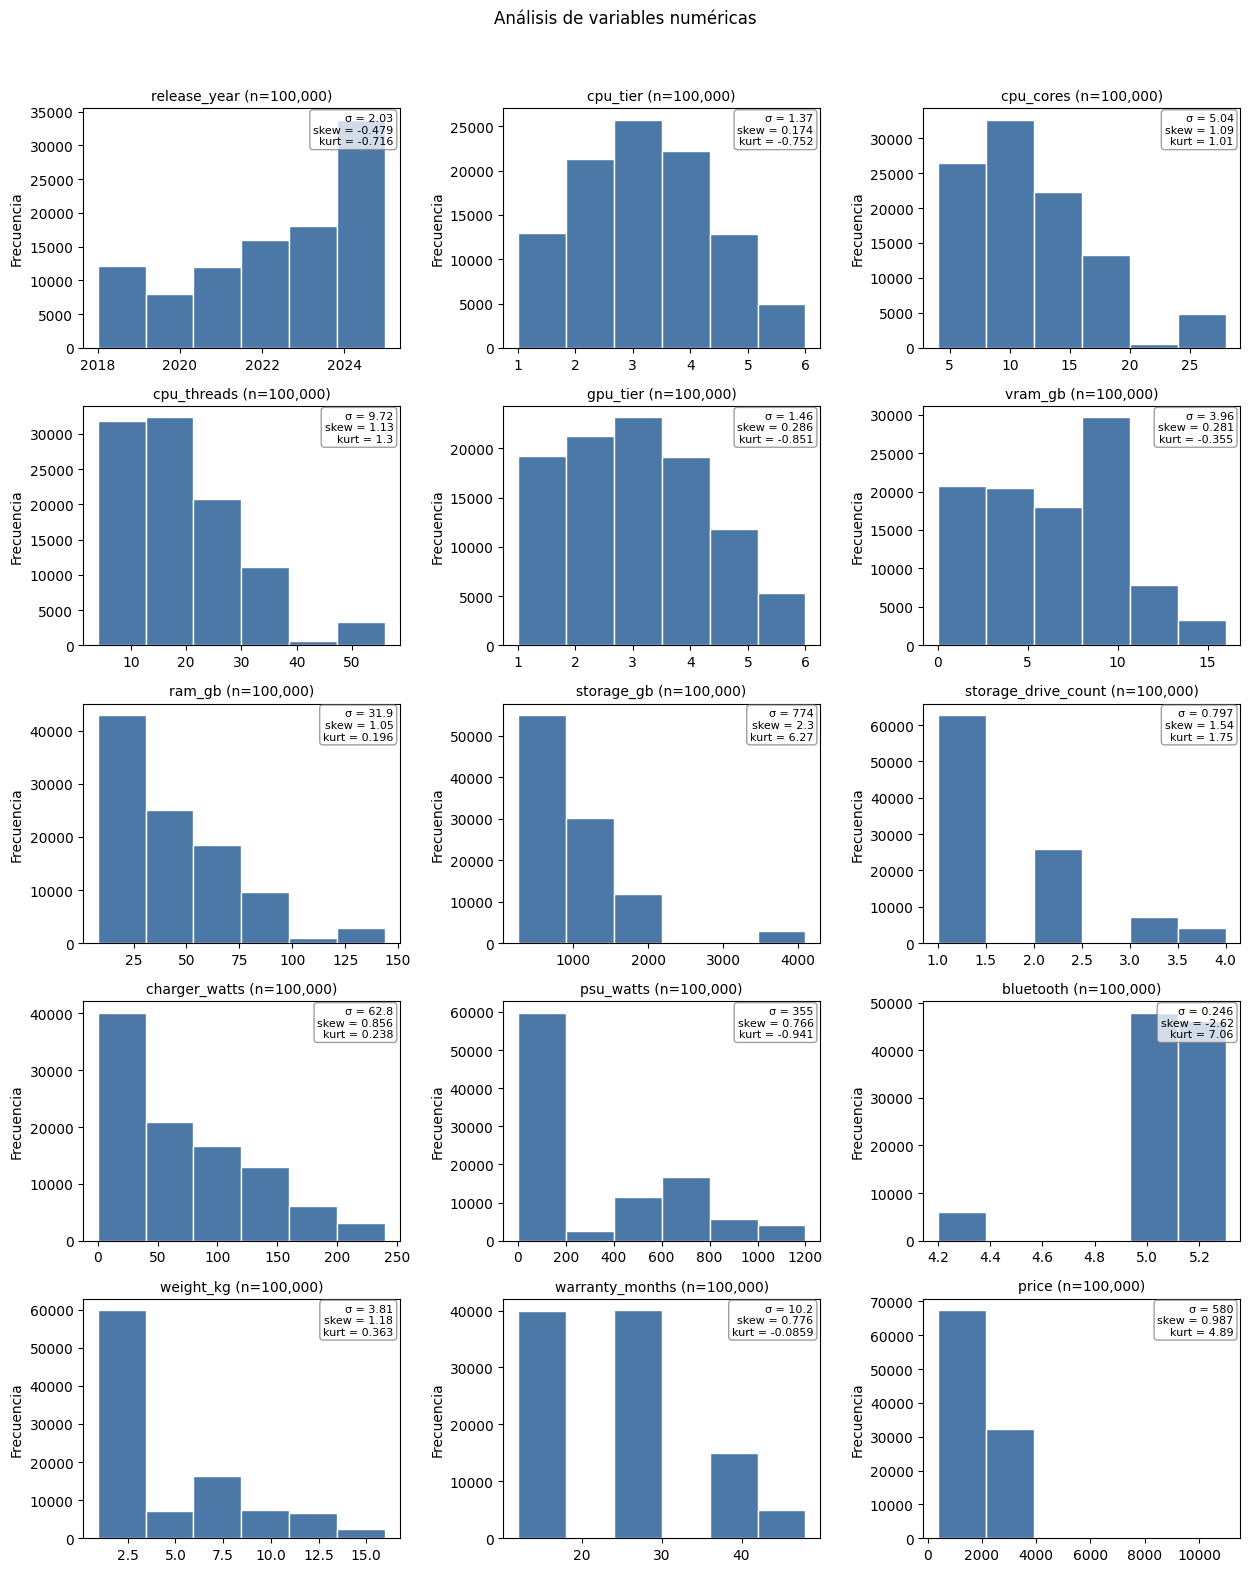

In [13]:
# Histogramas de variables numéricas
bins = 6
max_cols = 3
figsize_por_grafica = (4.2, 3.2)
titulo = "Análisis de variables numéricas"

columnas_numericas = compu_df.select_dtypes(include=[np.number]).columns.tolist()
n_cols = len(columnas_numericas)

ncols = min(max_cols, n_cols)
nrows = int(math.ceil(n_cols / ncols))

fig_w = figsize_por_grafica[0] * ncols
fig_h = figsize_por_grafica[1] * nrows
fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h))

if nrows == 1 and ncols == 1:
    axes = np.array([[axes]])
elif nrows == 1:
    axes = np.array([axes])
elif ncols == 1:
    axes = np.array([[ax] for ax in axes])

for i, col in enumerate(columnas_numericas):
    r, c = divmod(i, ncols)
    ax = axes[r, c]

    serie = compu_df[col].dropna().astype(float)
    ax.hist(serie, bins=bins, color="#4C78A8", edgecolor="white")

    n = serie.size
    std = serie.std(ddof=1) if n > 1 else np.nan
    skew = serie.skew() if n > 0 else np.nan
    kurt = serie.kurt() if n > 0 else np.nan

    texto = f"σ = {std:.3g}\nskew = {skew:.3g}\nkurt = {kurt:.3g}"
    ax.text(0.98, 0.98, texto, transform=ax.transAxes, ha="right", va="top",
            fontsize=8, bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="gray"))

    ax.set_title(f"{col} (n={n:,})", fontsize=10)
    ax.set_ylabel("Frecuencia")
    ax.set_xlabel("")

total_subplots = nrows * ncols
for j in range(n_cols, total_subplots):
    r, c = divmod(j, ncols)
    axes[r, c].axis('off')

fig.suptitle(titulo, fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])

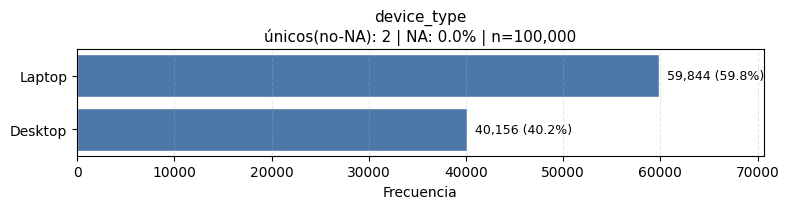

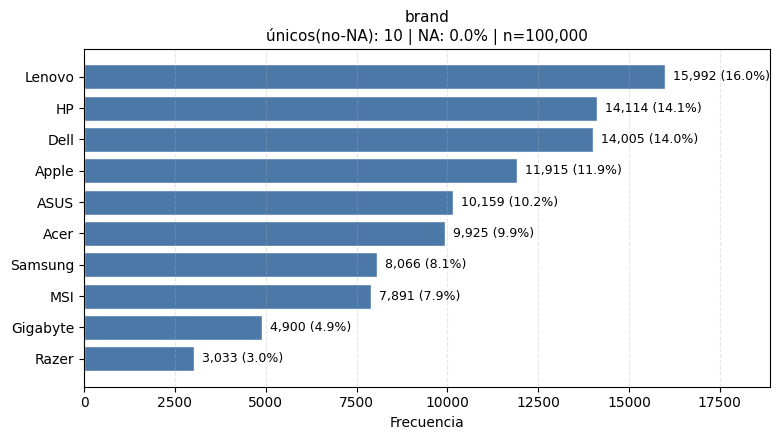

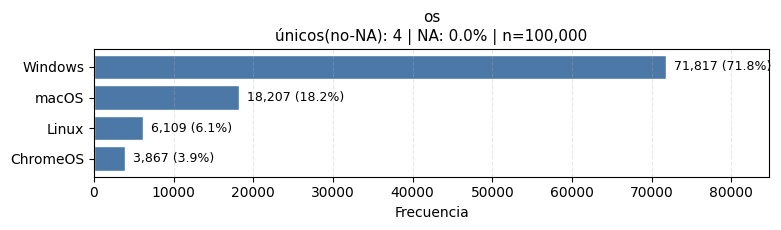

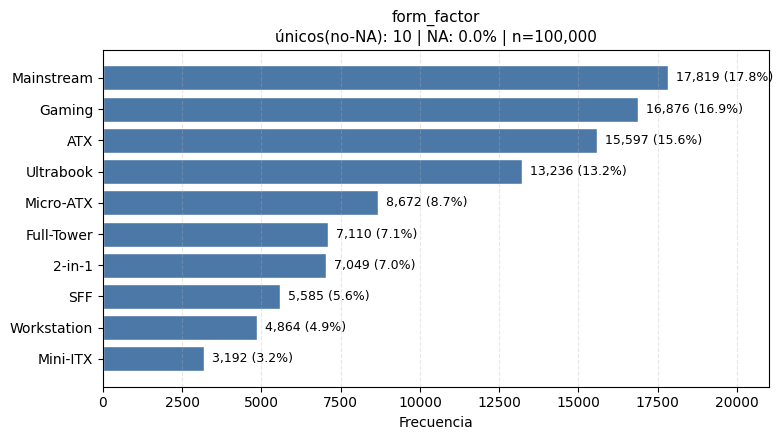

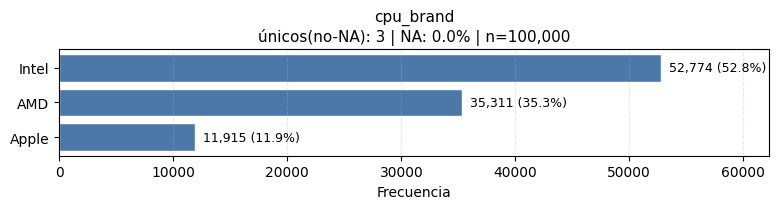

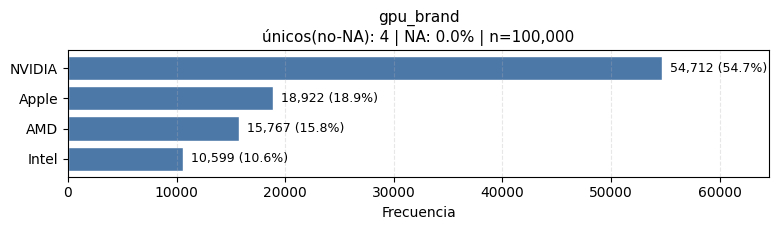

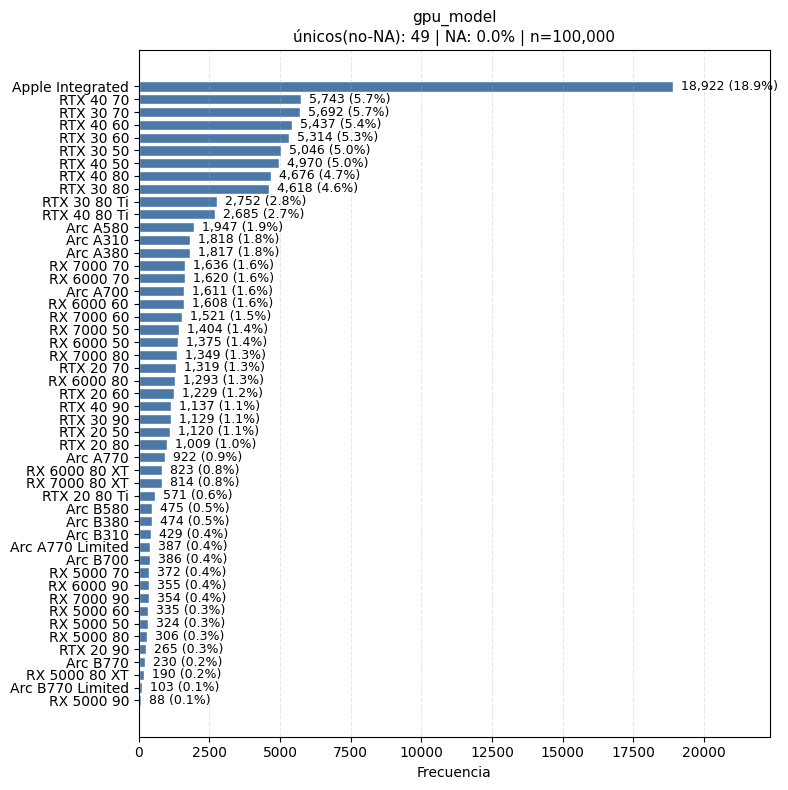

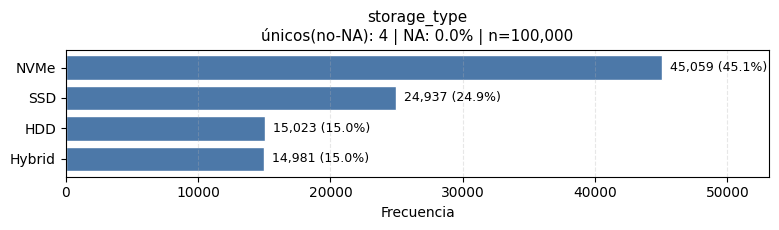

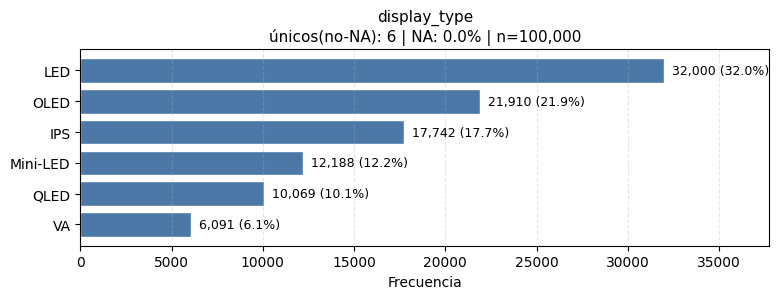

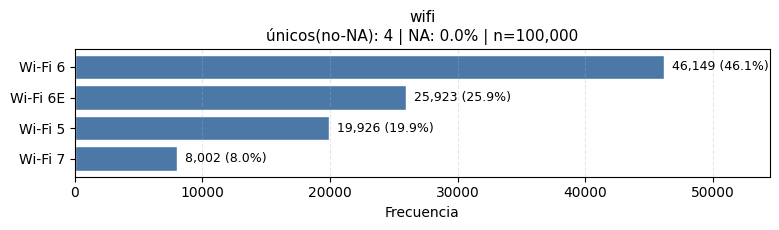

In [14]:
# visualización de variables categóricas (barras horizontales)

color_barras = "#4C78A8"

cat_types = ['object', 'string', 'category','bool']
columnas_cat = compu_df.select_dtypes(include=cat_types).columns.tolist()

# excluir compu_df.drop(columns=["model", "cpu_model"], inplace=True)
columnas_cat = [col for col in columnas_cat if col not in ["model", "cpu_model"]]

archivos_generados = []

n_total = len(compu_df)
for col in columnas_cat:
    s = compu_df[col]
    vc = s.value_counts(dropna=False)
    nunique = int(s.nunique(dropna=True))
    k = len(vc)
    vc_top = vc

    etiquetas = [("NaN" if pd.isna(x) else str(x)) for x in vc_top.index.tolist()]
    valores = vc_top.values
    porcentajes = (valores / n_total * 100.0)
    alto_por_barra = 0.35
    alto_min = 2.2
    alto_max = 8.0
    height = min(max(alto_min, alto_por_barra * len(etiquetas) + 1.0), alto_max)
    width = 8

    fig, ax = plt.subplots(figsize=(width, height))
    y_pos = np.arange(len(etiquetas))
    ax.barh(y_pos, valores, color=color_barras, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(etiquetas)
    ax.invert_yaxis()
    max_val = valores.max() if len(valores) > 0 else 1
    ax.set_xlim(0, max_val * 1.18)
    for y, (cnt, pct) in enumerate(zip(valores, porcentajes)):
        ax.text(cnt, y, f"  {cnt:,} ({pct:.1f}%)", va='center', ha='left', fontsize=9)

    na_pct = (s.isna().mean() * 100.0) if n_total > 0 else 0.0

    subtitulo = f"únicos(no-NA): {nunique} | NA: {na_pct:.1f}% | n={n_total:,}"
    ax.set_title(f"{col}\n{subtitulo}", fontsize=11)
    ax.set_xlabel("Frecuencia")
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    fig.tight_layout()


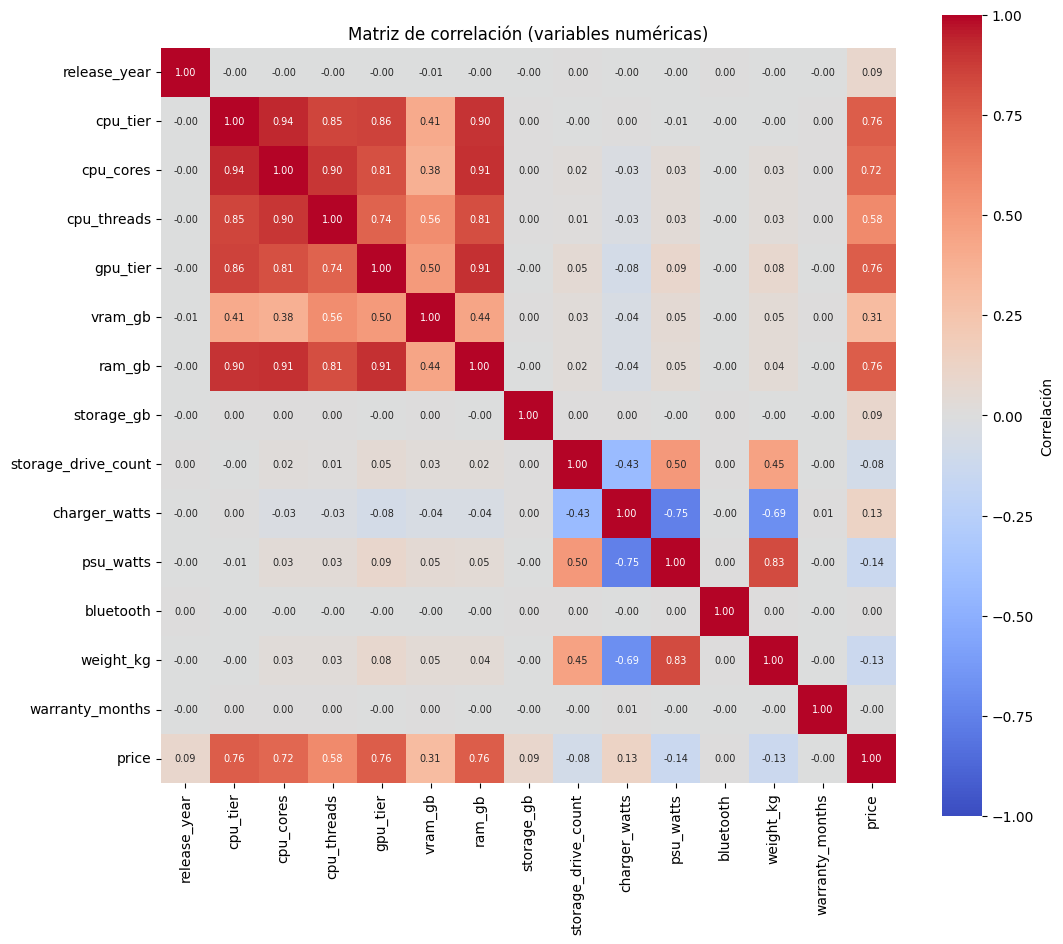

In [16]:
# Heatmap de correlación para variables numéricas
cols_num = compu_df.select_dtypes(include=[np.number]).columns.tolist()
base_num = compu_df[cols_num]
const_cols = base_num.columns[base_num.nunique(dropna=True) <= 1].tolist()
corr = base_num.corr(method="pearson")

n = corr.shape[0]
lado = max(6, min(0.6 * n + 2, 20))

fig, ax = plt.subplots(figsize=(lado, lado))
sns.heatmap(
    corr,
    ax=ax,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    annot=True, fmt='.2f',
    annot_kws={'fontsize': 7},
    cbar_kws={'shrink': 0.8, 'label': f'Correlación'}
)

ax.set_title('Matriz de correlación (variables numéricas)')
plt.tight_layout()
plt.show()

paso 4 feature engineering

In [15]:
# eliminar model y cpu_model
compu_df.drop(columns=["model", "cpu_model"], inplace=True)